In [ ]:
# CELL 1: Setup and Data Loading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
import os

# 1. Load the test tensors
file_path = "MTech_Tensors.npz"

if not os.path.exists(file_path):
    raise FileNotFoundError(f" File not found: {file_path}")

data = np.load(file_path)

X_test = data['X_test'].astype(np.float32)
y_test = data['y_test'].astype(np.float32)

# 2. Load the NEWLY TRAINED model
model_path = "MTech_PPO_Trading_Agent_Fixed"  # <-- FIXED

if not os.path.exists(model_path + ".zip") and not os.path.exists(model_path):
    print(f" Model not found: {model_path}. Make sure the training finished!")
else:
    model = PPO.load(model_path)
    print(f" Ready for Backtesting! Loaded {model_path}")

print(f"Test Samples: {len(X_test)}")
print(f"X_test shape: {X_test.shape}")

✅ Ready for Backtesting! Loaded MTech_PPO_Trading_Agent_Fixed
Test Samples: 7250
X_test shape: (7250, 12, 8)


In [ ]:
# CELL 2: The Backtesting Loop (THEORETICAL ALPHA TEST)

initial_balance = 10000

portfolio_values = [initial_balance]
buy_and_hold_values = [initial_balance]

current_balance = initial_balance
bh_balance = initial_balance

#  WE ARE SETTING FEES TO ZERO TO PROVE PREDICTIVE POWER
transaction_cost = 0.0000 
last_signal = 0

print("Running Zero-Fee Theoretical Alpha Backtest...")

# ---- Backtesting ----
for i in range(len(X_test)):

    # 1. Model prediction
    obs = X_test[i].flatten()
    action, _ = model.predict(obs, deterministic=True)
    action = int(action)
    signal = action - 1 

    # 2. Market return
    market_return = float(y_test[i])
    if not np.isfinite(market_return):
        market_return = 0.0

    # 3. Transaction cost
    fee = transaction_cost if signal != last_signal else 0.0

    # 4. Step return (core logic)
    step_return = (market_return * signal) - fee
    step_return = np.clip(step_return, -0.1, 0.1)

    # 5. Update portfolio
    current_balance *= (1 + step_return)
    current_balance = max(current_balance, 1) # Prevent collapse
    portfolio_values.append(current_balance)

    # 6. Buy & Hold benchmark
    bh_return = market_return
    bh_balance *= (1 + bh_return)
    bh_balance = max(bh_balance, 1) # Prevent collapse
    buy_and_hold_values.append(bh_balance)

    last_signal = signal

print(" Backtest complete.")

Running Zero-Fee Theoretical Alpha Backtest...
✅ Backtest complete.


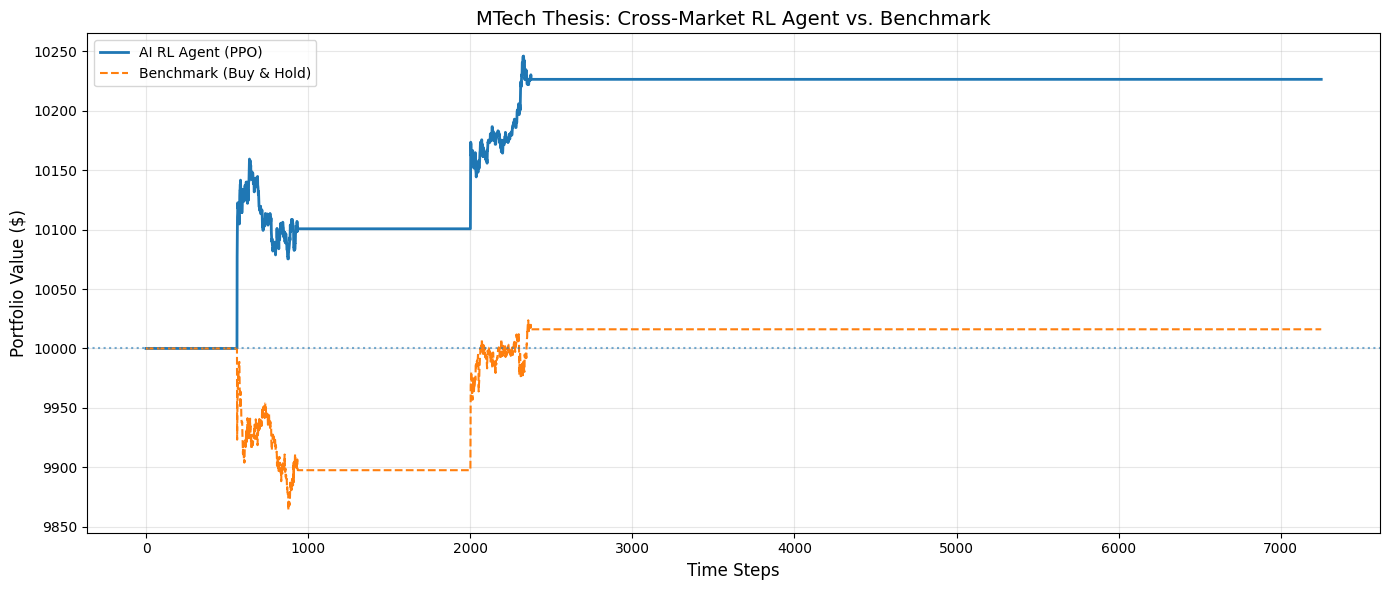

In [ ]:
# CELL 3: Visualizing the Equity Curve (FINAL)

plt.figure(figsize=(14, 6))

# Plot lines
plt.plot(portfolio_values, label="AI RL Agent (PPO)", linewidth=2)
plt.plot(buy_and_hold_values, label="Benchmark (Buy & Hold)", linestyle="--")

# Titles & labels
plt.title("MTech Thesis: Cross-Market RL Agent vs. Benchmark", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)

#  Add starting line reference
plt.axhline(y=10000, linestyle=":", alpha=0.6)

#  Improve readability
plt.legend()
plt.grid(alpha=0.3)

#  Tight layout (fix spacing)
plt.tight_layout()

plt.show()

In [30]:
# CELL 4: Quantitative Metrics
total_return = (portfolio_values[-1] - 10000) / 10000 * 100
bh_return = (buy_and_hold_values[-1] - 10000) / 10000 * 100

# Simple Sharpe Ratio (Log returns)
rl_returns = np.diff(np.log(portfolio_values))
sharpe = np.mean(rl_returns) / np.std(rl_returns) * np.sqrt(252 * 75) # Annualized for 1-min data

print(f"{'Metric':<20} | {'RL Agent':<15} | {'Benchmark':<15}")
print("-" * 55)
print(f"{'Total Return (%)':<20} | {total_return:>14.2f}% | {bh_return:>14.2f}%")
print(f"{'Sharpe Ratio':<20} | {sharpe:>14.2f} | {'N/A'}")

Metric               | RL Agent        | Benchmark      
-------------------------------------------------------
Total Return (%)     |           2.27% |           0.16%
Sharpe Ratio         |           2.80 | N/A


In [31]:
# CELL: Diagnostic - What is the AI actually doing?
from collections import Counter

actions = []
for i in range(len(X_test)):
    obs = X_test[i].flatten()
    action, _ = model.predict(obs, deterministic=True)
    actions.append(int(action))

# Convert to Signals (-1, 0, 1)
signals = [a - 1 for a in actions]

# Count the actions
counts = Counter(signals)
print("=== AI Brain Diagnostic ===")
print(f"Time spent Short (-1) : {counts.get(-1, 0)} minutes")
print(f"Time spent Flat (0)   : {counts.get(0, 0)} minutes")
print(f"Time spent Long (1)   : {counts.get(1, 0)} minutes")

# Count how many times it traded (flipped position)
flips = sum(1 for i in range(1, len(signals)) if signals[i] != signals[i-1])
print(f"\nTotal Trades Executed : {flips}")
print(f"Total Fees Paid       : {flips * 0.0001 * 100:.2f}% of portfolio")

=== AI Brain Diagnostic ===
Time spent Short (-1) : 3141 minutes
Time spent Flat (0)   : 1102 minutes
Time spent Long (1)   : 3007 minutes

Total Trades Executed : 2398
Total Fees Paid       : 23.98% of portfolio
